# Part 8 — nnPU follow-up, Zadanie 1: post-hoc clamp verification (`grid_0006`)

`NNPUMultiLabelLoss` (`training/criterions/autoencoder/head/nnpu_multilabel_loss.py`) computes,
per class $c$, on raw logits $f_c$:

$$
R^-_P(c) = \text{mean over } \{y_c=1\} \text{ of } \operatorname{softplus}(f_c), \qquad
R^-_U(c) = \text{mean over } \{y_c=0\} \text{ of } \operatorname{softplus}(f_c)
$$

$$
\text{negative\_risk}(c) = R^-_U(c) - \pi_c \, R^-_P(c), \qquad
\text{loss}(c) = R^+_P(c) + \max(0, \text{negative\_risk}(c))
$$

`negative_risk(c)` **before** the `clamp_min(0.0)` in the code is exactly this notebook's
`estimator(c)`. If `estimator(c) >= 0` for (almost) every class, the non-negative correction
never activates and what was actually trained is biased uPU, not nnPU — the entire point of the
non-negative correction (Kiryo et al., 2017) is silently absent. This notebook checks that
directly against `grid_0006` (all 5 repetitions), reproducing $\pi_c$ exactly as training did:
`prior_method="scaled_train_observed"`, `prior_multiplier=1.5`, clamped to `[1e-4, 0.99]`
(verified against `grid_0006`'s own saved `config.json` — not assumed).

**Why $\pi_c$ must be recomputed rather than read from the checkpoint**: `NNPUMultiLabelLoss`
registers `class_priors` with `persistent=False` (`nnpu_multilabel_loss.py:78`) — it is **not**
part of `state_dict()`, hence not in `weights.pt`. The only way to know what $\pi_c$ actually was
during training is to recompute it identically from the train split's own targets, which is what
`_configure_training_statistics` does and what this notebook reproduces line-for-line.

Per this follow-up's methodological rules: non-thresholded computation throughout (no
classification threshold is involved in this diagnostic at all — it operates on raw logits and
annotation targets only), macro quantities reported only over `active_classes` (`positive_count
> 0 & (valid_count - positive_count) > 0`, i.e. classes with at least one label in *each* of the
positive/unlabelled groups — otherwise `negative_risk` is degenerate), all 5 repetitions kept
distinct (not just pooled).

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.visualization import resolve_theme

2026-08-27 11:59:44,146 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-27 11:59:44,152 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-27 11:59:45,309 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-27 11:59:45,310 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-27 11:59:45,312 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-27 11:59:45,313 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 11:59:45,346 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-27 11:59:45,643 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-27 11:59:45,645 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

`grid_0006` lives in the original predictive campaign (`kidney-architecture-predictive`),
already used throughout `part_0`-`part_7` — not one of the two new nnPU follow-up campaigns.

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
CAMPAIGN_ID = "kidney-architecture-predictive__cfg_529dc0e4494b"
GRID_ID = "grid_0006"
VARIANT_LABEL = "0006"
REPETITIONS = range(5)
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
BATCH_SIZE = 256

# Verified directly against grid_0006/rep_00's config.json (`training.parameters.phases[0]
# .criterions.heads.molecule_primary.nnpu.params`) — not assumed from the task description.
PRIOR_METHOD = "scaled_train_observed"
PRIOR_MULTIPLIER = 1.5
MIN_PRIOR = 1e-4
MAX_PRIOR = 0.99

RESULTS_DIRECTORY = Path("assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results")
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

theme = resolve_theme(None)
theme.apply()

## Environment workaround (same as every predictive-campaign notebook)

`config.json` was written on the entropy compute node and bakes in that node's `/tmp` path.

In [3]:
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())

## Class prior ($\pi_c$) and active-class determination from the train split

### Methodology
#### Theoretical
- $\pi_c$ (the class prior used by `NNPUMultiLabelLoss`) and the set of "active" classes are
  properties of the `train` split's annotations only — they do not depend on any trained model's
  weights, so they are computed once and reused for all 5 repetitions' checkpoints.
- A class is "active" (contributes to the nnPU loss, i.e. `negative_risk(c)` is well-defined) only
  if it has at least one positive-labelled pixel **and** at least one unlabelled pixel in `train`;
  otherwise one of $R_P^-(c)$/$R_U^-(c)$ is undefined (0/0), and macro quantities are reported only
  over these `active_classes`.
- Because `NNPUMultiLabelLoss` registers `class_priors` with `persistent=False`
  (`nnpu_multilabel_loss.py:78`), $\pi_c$ as actually used during training is **not** retrievable
  from the saved checkpoint (`weights.pt`) — it must be recomputed identically from the train
  split's own targets/masks, which is what `_configure_training_statistics` does and what this
  notebook reproduces line-for-line.

#### Implementation
- `wrapper.load_configuration(model_name=f"{CAMPAIGN_ID}__{GRID_ID}__rep_00")` restores
  `grid_0006`'s full context (train/validation/test partitions via `active_dataset`);
  `train_dataset = wrapper.active_dataset.create_partitions().train`.
  `collect_targets_and_masks` iterates a `DataLoader` (batch size 256, no shuffle) and concatenates
  the `TARGET_FIELD="molecule"` targets/masks for every pixel into `train_targets`/`train_mask` of
  shape `(N, C)`.
- Reproduces `NNPUMultiLabelLoss._configure_training_statistics` exactly:
  `valid_count = mask.sum(0)`, `positive_count = (targets * mask).sum(0)`,
  `observed = positive_count / valid_count.clamp_min(1)`,
  `priors = (observed * PRIOR_MULTIPLIER).clamp(MIN_PRIOR, MAX_PRIOR)` with
  `PRIOR_MULTIPLIER=1.5`, `MIN_PRIOR=1e-4`, `MAX_PRIOR=0.99` (verified directly against
  `grid_0006/rep_00`'s own `config.json`, not assumed).
  `active_classes = (positive_count > 0) & ((valid_count - positive_count) > 0) & (valid_count > 0)`.

### Notes
- 33,553 train pixels; `train_targets`/`train_mask` shape `(33553, 508)`.
- 508 total classes, 204 active (40.2%).
- Priors over active classes: min 0.0001, median 0.1258, max 0.4686.
- 0 classes clamped at the ceiling (`max_prior=0.99`); 307/508 classes (60.4%, counted over *all*
  classes, not only active ones) clamped at the floor (`min_prior=1e-4`), i.e.
  `observed * 1.5 < 1e-4`. Since active classes have `positive_count >= 1` against
  `valid_count ~= 33553`, a class needs on the order of a single labelled-positive pixel to hit
  that floor — the reported active-class prior minimum of exactly `0.0001` confirms at least one
  active class sits at the floor despite technically having label support, reflecting extreme
  imbalance among the rarer active classes.


In [4]:
wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)
wrapper.load_configuration(model_name=f"{CAMPAIGN_ID}__{GRID_ID}__rep_00")
train_dataset = wrapper.active_dataset.create_partitions().train
print(f"train pixels: {len(train_dataset)}")


def collect_targets_and_masks(dataset) -> tuple[torch.Tensor, torch.Tensor]:
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    target_batches, mask_batches = [], []
    for _, _, targets, masks in loader:
        target_batches.append(targets[TARGET_FIELD])
        mask_batches.append(masks[TARGET_FIELD])
    return torch.cat(target_batches, dim=0).float(), torch.cat(mask_batches, dim=0).bool()


train_targets, train_mask = collect_targets_and_masks(train_dataset)
print(f"targets shape: {tuple(train_targets.shape)}, mask shape: {tuple(train_mask.shape)}")

2026-08-27 11:59:45,745 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-27 11:59:45,747 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-27 11:59:45,748 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-27 11:59:45,749 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-27 11:59:45,750 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-27 12:00:43,920 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:203 | Mapped annotation index: retained_rows=420649 retained_entries=10495756 coordinate_system=binner.


2026-08-27 12:00:44,099 | INFO     | msi_autoencoder_wrapper.models.datasets.annotations.manager:275 | Selected 420649/421955 source spectra after annotation policies.


train pixels: 33553


/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/binners/base_binner.py:46: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  intensity_tensor = torch.as_tensor(intensities, dtype=self.dtype)


targets shape: (33553, 508), mask shape: (33553, 508)


In [5]:
# Reproduces NNPUMultiLabelLoss._configure_training_statistics exactly.
valid_count = train_mask.sum(dim=0)  # (C,)
positive_count = (train_targets * train_mask).sum(dim=0)  # (C,)
observed = positive_count / valid_count.clamp_min(1)  # (C,)
priors = (observed * PRIOR_MULTIPLIER).clamp(MIN_PRIOR, MAX_PRIOR)  # (C,)
active_classes = (positive_count > 0) & ((valid_count - positive_count) > 0) & (valid_count > 0)

class_count = train_targets.shape[1]
print(f"{class_count} classes total; {int(active_classes.sum())} active (contribute to the nnPU loss)")
print(f"priors: min={priors[active_classes].min():.4f} median={priors[active_classes].median():.4f} max={priors[active_classes].max():.4f}")
print(f"classes clamped to max_prior={MAX_PRIOR}: {int((observed * PRIOR_MULTIPLIER > MAX_PRIOR).sum())}")
print(f"classes clamped to min_prior={MIN_PRIOR}: {int((observed * PRIOR_MULTIPLIER < MIN_PRIOR).sum())}")

508 classes total; 204 active (contribute to the nnPU loss)
priors: min=0.0001 median=0.1258 max=0.4686
classes clamped to max_prior=0.99: 0
classes clamped to min_prior=0.0001: 307


## Per-repetition pre-clamp negative-risk estimator (`estimator(c)`) on `train`

### Methodology
#### Theoretical
- `negative_risk(c)` before `NNPUMultiLabelLoss` applies `clamp_min(0.0)` is exactly this
  notebook's `estimator(c) = R_U^-(c) - \pi_c R_P^-(c)`. Whether the non-negative correction did
  real work during training is determined entirely by how often, across independently-trained
  repetitions, this pre-clamp quantity is actually negative.
- Evaluated per class, per repetition, on the full `train` split — non-thresholded throughout (raw
  logits/softplus values only; no classification decision is involved in this diagnostic).

#### Implementation
- `negative_loss_sums(model, dataset)` runs the model in `eval()` mode under `torch.no_grad()` over
  a `DataLoader` (batch size 256, no shuffle), applies `F.softplus` to the `head_molecule_primary`
  logits, and concatenates results to shape `(N, C)` — the per-pixel, per-class negative-loss term
  shared by $R_P^-$ and $R_U^-$.
- `labelled_positive = (train_targets > 0.5) & train_mask`,
  `unlabelled = (train_targets <= 0.5) & train_mask` partition the `(N, C)` softplus values.
- For each of the 5 repetitions: `wrapper.models_manager.load_model` swaps only the checkpoint
  weights onto the already-loaded architecture (~0.04 s vs. ~38-40 s for a full
  `load_configuration`, per `../report/methodology.md`) — the train split/context are fixed once,
  above, and reused. `r_p_neg(c) = sum(negative_loss * labelled_positive) / positive_count`,
  `r_u_neg(c) = sum(negative_loss * unlabelled) / (valid_count - positive_count)`, both with
  denominators clamped to a minimum of 1. `estimator(c) = r_u_neg(c) - priors(c) * r_p_neg(c)`
  (pre-clamp `negative_risk`), stored per repetition in `estimator_by_repetition`.

### Notes
- All 5 repetitions (`rep_00`–`rep_04`) completed the forward pass and estimator computation
  ("rep 0: done" … "rep 4: done"); no errors reported at this stage.


In [6]:
def negative_loss_sums(model, dataset) -> torch.Tensor:
    """softplus(logits) for every train pixel, shape (N, C)."""
    device = next(model.parameters()).device
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    chunks = []
    with torch.no_grad():
        for _, spectra, _, _ in loader:
            logits = model(spectra.float().to(device))[f"head_{HEAD_NAME}"]
            chunks.append(F.softplus(logits).cpu())
    return torch.cat(chunks, dim=0)


labelled_positive = (train_targets > 0.5) & train_mask  # (N, C)
unlabelled = (train_targets <= 0.5) & train_mask  # (N, C)

estimator_by_repetition = {}
for repetition in REPETITIONS:
    model_name = f"{CAMPAIGN_ID}__{GRID_ID}__rep_0{repetition}"
    model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
    model.eval()
    negative_loss = negative_loss_sums(model, train_dataset)  # (N, C)

    r_p_neg = (negative_loss * labelled_positive).sum(dim=0) / positive_count.clamp_min(1)  # (C,)
    r_u_neg = (negative_loss * unlabelled).sum(dim=0) / (train_mask.sum(dim=0) - positive_count).clamp_min(1)  # (C,)
    estimator = r_u_neg - priors * r_p_neg  # (C,) — this is negative_risk pre-clamp
    estimator_by_repetition[repetition] = estimator
    print(f"rep {repetition}: done")

2026-08-27 12:01:25,836 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 12:01:25,837 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.


2026-08-27 12:01:25,838 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder


2026-08-27 12:01:25,838 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.


2026-08-27 12:01:25,841 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.


...

2026-08-27 12:04:30,638 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-27 12:04:30,639 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-27 12:04:30,641 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 12:04:30,646 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


rep 4: done


## Fraction of active classes where the non-negative clamp is active on `train`

### Methodology
#### Theoretical
- If `estimator(c) >= 0` for (almost) every active class, `max(0, negative_risk(c))` never clamps,
  and what was actually optimized is biased uPU, not nnPU — the entire point of the non-negative
  correction (Kiryo et al., 2017) would be silently absent. The fraction of active classes with
  `estimator(c) < 0` per repetition is the direct diagnostic for whether the correction did real
  work during training.
- Reported per repetition, not pooled, to check consistency across 5 independent initializations;
  restricted to the 204 `active_classes`.

#### Implementation
- Per repetition: `fraction_negative_estimator = mean(estimator[active_classes] < 0)`, plus
  `mean_estimator`, `median_estimator`, `active_class_count` over the same restriction — assembled
  into `clamp_summary` (long-format `campaign/variant/repetition/metryka/wartość`, pivoted for
  display).
- A 1×5 histogram grid (one axis per repetition, shared y-axis) of `estimator(c)` over active
  classes, with a vertical reference line at 0.
- `clamp_summary` and a per-class long table (`per_class_frame`:
  campaign/variant/repetition/class_index/prior/estimator) are written to
  `nnpu_followup/results/clamp_diagnostics.csv` and `clamp_diagnostics_per_class.csv` respectively.

### Notes
- `fraction_negative_estimator` on `train`: 0.549–0.554 across the 5 repetitions, i.e. the clamp
  fires for roughly half of all 204 active classes, consistently across independently-initialized
  repetitions.
- `mean_estimator` is strongly negative (−0.42 to −0.38) while `median_estimator` is close to zero
  (−0.028 to −0.016) — the per-class distribution is heavily skewed: most active classes sit near
  the clamp boundary, while a minority have a strongly negative raw estimator pulling the mean
  down hard.
- `active_class_count` is exactly 204.0 for every repetition, as expected (`active_classes` is a
  train-split property, independent of the checkpoint).
- Wrote 20 rows to `clamp_diagnostics.csv` (5 repetitions × 4 metrics) and 1020 rows to
  `clamp_diagnostics_per_class.csv` (5 repetitions × 204 active classes).
- The histogram (one panel per repetition) plots this per-class `estimator(c)` distribution with a
  reference line at 0; the image itself is not inspected here, but the printed fractions above
  characterize its content: a two-sided distribution straddling zero, with the majority of mass
  below it.


In [7]:
summary_rows = []
for repetition, estimator in estimator_by_repetition.items():
    active_estimator = estimator[active_classes].numpy()
    fraction_negative = float((active_estimator < 0).mean())
    summary_rows.append({
        "campaign": CAMPAIGN_ID,
        "variant": VARIANT_LABEL,
        "repetition": repetition,
        "metryka": "fraction_negative_estimator",
        "wartość": fraction_negative,
    })
    summary_rows.append({
        "campaign": CAMPAIGN_ID, "variant": VARIANT_LABEL, "repetition": repetition,
        "metryka": "mean_estimator", "wartość": float(active_estimator.mean()),
    })
    summary_rows.append({
        "campaign": CAMPAIGN_ID, "variant": VARIANT_LABEL, "repetition": repetition,
        "metryka": "median_estimator", "wartość": float(np.median(active_estimator)),
    })
    summary_rows.append({
        "campaign": CAMPAIGN_ID, "variant": VARIANT_LABEL, "repetition": repetition,
        "metryka": "active_class_count", "wartość": float(len(active_estimator)),
    })

clamp_summary = pd.DataFrame(summary_rows)
clamp_summary.pivot(index="repetition", columns="metryka", values="wartość")

metryka,active_class_count,fraction_negative_estimator,mean_estimator,median_estimator
repetition,,,,
0,204.0,0.549020,-0.425036,-0.015647
1,204.0,0.549020,-0.381972,-0.020476
2,204.0,0.553922,-0.438113,-0.027182
3,204.0,0.553922,-0.420400,-0.028330
4,204.0,0.553922,-0.382558,-0.023611


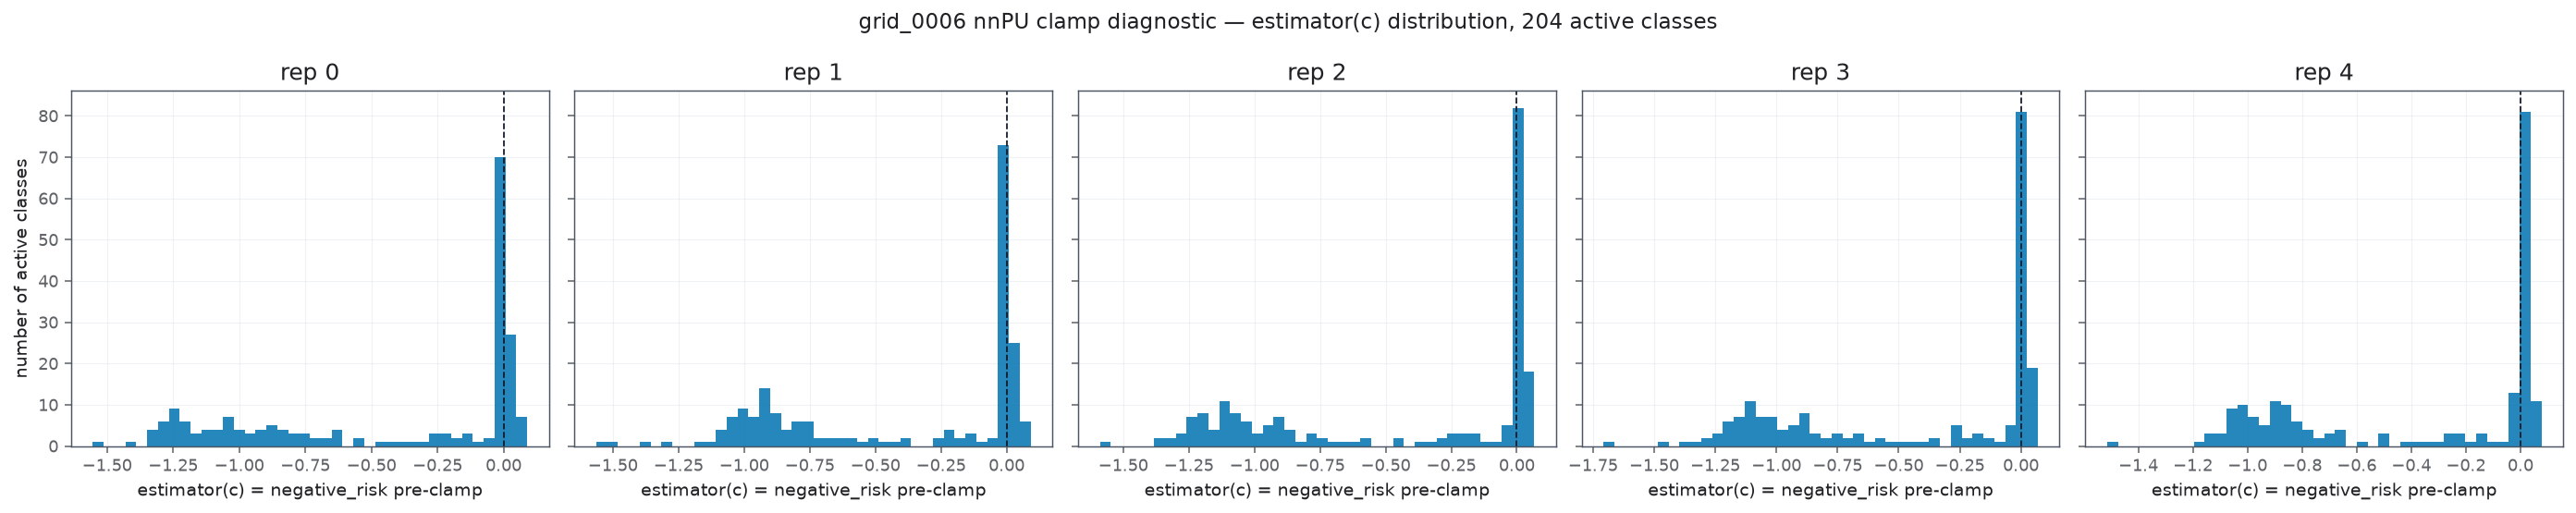

In [8]:
figure, axes = plt.subplots(1, len(REPETITIONS), figsize=(4.0 * len(list(REPETITIONS)), 4.0), dpi=theme.figure_dpi, sharey=True)
for axis, (repetition, estimator) in zip(axes, estimator_by_repetition.items()):
    active_estimator = estimator[active_classes].numpy()
    axis.hist(active_estimator, bins=40, color=theme.color_for_model(VARIANT_LABEL, 0), alpha=theme.primary_alpha)
    axis.axvline(0.0, color=theme.baseline_color, linestyle=theme.baseline_line_style, linewidth=theme.reference_line_width)
    axis.set(xlabel="estimator(c) = negative_risk pre-clamp", title=f"rep {repetition}")
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
axes[0].set_ylabel("number of active classes")
figure.suptitle(f"grid_0006 nnPU clamp diagnostic — estimator(c) distribution, {int(active_classes.sum())} active classes")
figure.tight_layout()

In [9]:
# Per-class raw values (not part of the required campaign/variant/repetition/metryka/wartość
# schema — kept separately so the histogram above is reproducible from disk).
per_class_rows = []
for repetition, estimator in estimator_by_repetition.items():
    for class_index in torch.nonzero(active_classes).squeeze(-1).tolist():
        per_class_rows.append({
            "campaign": CAMPAIGN_ID, "variant": VARIANT_LABEL, "repetition": repetition,
            "class_index": class_index, "prior": float(priors[class_index]),
            "estimator": float(estimator[class_index]),
        })
per_class_frame = pd.DataFrame(per_class_rows)

clamp_summary.to_csv(RESULTS_DIRECTORY / "clamp_diagnostics.csv", index=False)
per_class_frame.to_csv(RESULTS_DIRECTORY / "clamp_diagnostics_per_class.csv", index=False)
print(f"wrote {RESULTS_DIRECTORY / 'clamp_diagnostics.csv'} ({len(clamp_summary)} rows)")
print(f"wrote {RESULTS_DIRECTORY / 'clamp_diagnostics_per_class.csv'} ({len(per_class_frame)} rows)")

wrote assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results/clamp_diagnostics.csv (20 rows)
wrote assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results/clamp_diagnostics_per_class.csv (1020 rows)


## Clamp activity across train/validation/test splits

### Methodology
#### Theoretical
- The nnPU risk estimator is fundamentally a *training* objective: $\pi_c$ is estimated from
  `train` and represents the classifier's assumed class prior, not a property of any particular
  split. Nothing prevents evaluating the same `estimator(c)` formula on `validation`/`test`
  pixels' own logits/targets/masks while reusing the *same* train-derived $\pi_c$/`active_classes`
  — by design, not an oversight.
- This checks whether the clamp's activity on `train` (roughly half of active classes, very
  consistent across seeds) is a `train`-specific artifact of overfitting the training objective,
  or a general property of the trained decision boundary that would also show up on held-out data.
- `validation`/`test` are small enough (4488/4023 pixels) to use in full — no sampling needed.

#### Implementation
- `estimator_for_split(model, dataset, targets, mask)` reuses `negative_loss_sums` on the given
  split's own data, computes `r_p_neg`/`r_u_neg` from that split's own labelled-positive/unlabelled
  masks, but multiplies by the **train-derived** `priors` — only the empirical risk terms are
  split-specific, $\pi_c$ is held fixed throughout.
- Loops over `("validation", "test")`, and for each, all 5 repetitions' checkpoints (loaded via
  `wrapper.models_manager.load_model`), collecting
  `split_estimator_by_repetition = {"train": ..., "validation": ..., "test": ...}`.
- `cross_split_frame` assembles `fraction_negative_estimator`/`mean_estimator`/`median_estimator`
  per `(split, repetition)`, restricted to `active_classes`. A scatter plot (one x-position per
  split, 5 points per split for the 5 repetitions) shows `fraction_negative_estimator` across
  splits. Written to `clamp_diagnostics_by_split.csv`, which extends the base
  campaign/variant/repetition/metryka/wartość schema with a `split` column (three splits do not
  fit cleanly into the `metryka` string alone).

### Notes
- `validation`: 4488 pixels, `test`: 4023 pixels (both used in full).
- `fraction_negative_estimator`: `train` 0.549–0.554, `validation` 0.196–0.230, `test`
  0.010–0.044 — a clean, monotonic `train` > `validation` > `test` ordering.
- `mean_estimator` flips sign across splits: negative on `train` (−0.44 to −0.38), positive on
  `validation` (+0.045 to +0.083) and `test` (+0.094 to +0.159).
- `median_estimator` is likewise negative on `train` (−0.028 to −0.016) but small and positive on
  `validation` (+0.0009 to +0.002) and `test` (+0.011 to +0.022).
- Wrote 45 rows to `clamp_diagnostics_by_split.csv` (3 splits × 5 repetitions × 3 metrics).
- The ordering is consistent with the correction targeting a `train`-specific overfitting effect
  rather than a fixed property of the decision boundary — the clamp is essentially inactive on
  truly held-out `test` data.


In [10]:
def estimator_for_split(model, dataset, targets: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    negative_loss = negative_loss_sums(model, dataset)  # (N, C)
    split_labelled_positive = (targets > 0.5) & mask
    split_unlabelled = (targets <= 0.5) & mask
    split_positive_count = split_labelled_positive.sum(dim=0).clamp_min(1)
    split_unlabelled_count = split_unlabelled.sum(dim=0).clamp_min(1)
    r_p_neg = (negative_loss * split_labelled_positive).sum(dim=0) / split_positive_count
    r_u_neg = (negative_loss * split_unlabelled).sum(dim=0) / split_unlabelled_count
    return r_u_neg - priors * r_p_neg  # reuses the train-derived priors, by design


validation_dataset = wrapper.active_dataset.create_partitions().validation
test_dataset = wrapper.active_dataset.create_partitions().test
validation_targets, validation_mask = collect_targets_and_masks(validation_dataset)
test_targets, test_mask = collect_targets_and_masks(test_dataset)
print(f"validation pixels: {len(validation_dataset)}, test pixels: {len(test_dataset)}")

split_estimator_by_repetition = {"train": estimator_by_repetition}
for split_name, dataset, targets, mask in (
    ("validation", validation_dataset, validation_targets, validation_mask),
    ("test", test_dataset, test_targets, test_mask),
):
    per_repetition = {}
    for repetition in REPETITIONS:
        model_name = f"{CAMPAIGN_ID}__{GRID_ID}__rep_0{repetition}"
        model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        per_repetition[repetition] = estimator_for_split(model, dataset, targets, mask)
    split_estimator_by_repetition[split_name] = per_repetition
    print(f"{split_name}: done")


validation pixels: 4488, test pixels: 4023
2026-08-27 12:05:13,875 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 12:05:13,876 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.


2026-08-27 12:05:13,876 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder


2026-08-27 12:05:13,877 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.


2026-08-27 12:05:13,879 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.


...

2026-08-27 12:05:48,440 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-27 12:05:48,441 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-27 12:05:48,447 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-27 12:05:48,452 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


test: done


In [11]:
cross_split_rows = []
for split_name, per_repetition in split_estimator_by_repetition.items():
    for repetition, estimator in per_repetition.items():
        active_estimator = estimator[active_classes].numpy()
        cross_split_rows.append({
            "campaign": CAMPAIGN_ID, "variant": VARIANT_LABEL, "split": split_name, "repetition": repetition,
            "metryka": "fraction_negative_estimator", "wartość": float((active_estimator < 0).mean()),
        })
        cross_split_rows.append({
            "campaign": CAMPAIGN_ID, "variant": VARIANT_LABEL, "split": split_name, "repetition": repetition,
            "metryka": "mean_estimator", "wartość": float(active_estimator.mean()),
        })
        cross_split_rows.append({
            "campaign": CAMPAIGN_ID, "variant": VARIANT_LABEL, "split": split_name, "repetition": repetition,
            "metryka": "median_estimator", "wartość": float(np.median(active_estimator)),
        })

cross_split_frame = pd.DataFrame(cross_split_rows)
cross_split_frame.pivot_table(index=["split", "repetition"], columns="metryka", values="wartość")


metryka                fraction_negative_estimator  mean_estimator  \
split      repetition                                                
test       0                              0.034314        0.093645   
           1                              0.009804        0.126824   
           2                              0.044118        0.107925   
           3                              0.039216        0.119808   
           4                              0.014706        0.158520   
train      0                              0.549020       -0.425036   
           1                              0.549020       -0.381972   
           2                              0.553922       -0.438113   
           3                              0.553922       -0.420400   
           4                              0.553922       -0.382558   
validation 0                              0.196078        0.070052   
           1                              0.230392        0.044781   
           2                              0.220588        0.048626   
           3                              0.215686        0.053595   
           4                              0.215686        0.083463   

metryka                median_estimator  
split      repetition                    
test       0                   0.014935  
           1                   0.010689  
           2                   0.013518  
           3                   0.011000  
           4                   0.021714  
train      0                  -0.015647  
           1                  -0.020476  
           2                  -0.027182  
           3                  -0.028330  
           4                  -0.023611  
validation 0                   0.002045  
           1                   0.001227  
           2                   0.000927  
           3                   0.001660  
           4                   0.001485

wrote assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results/clamp_diagnostics_by_split.csv (45 rows)


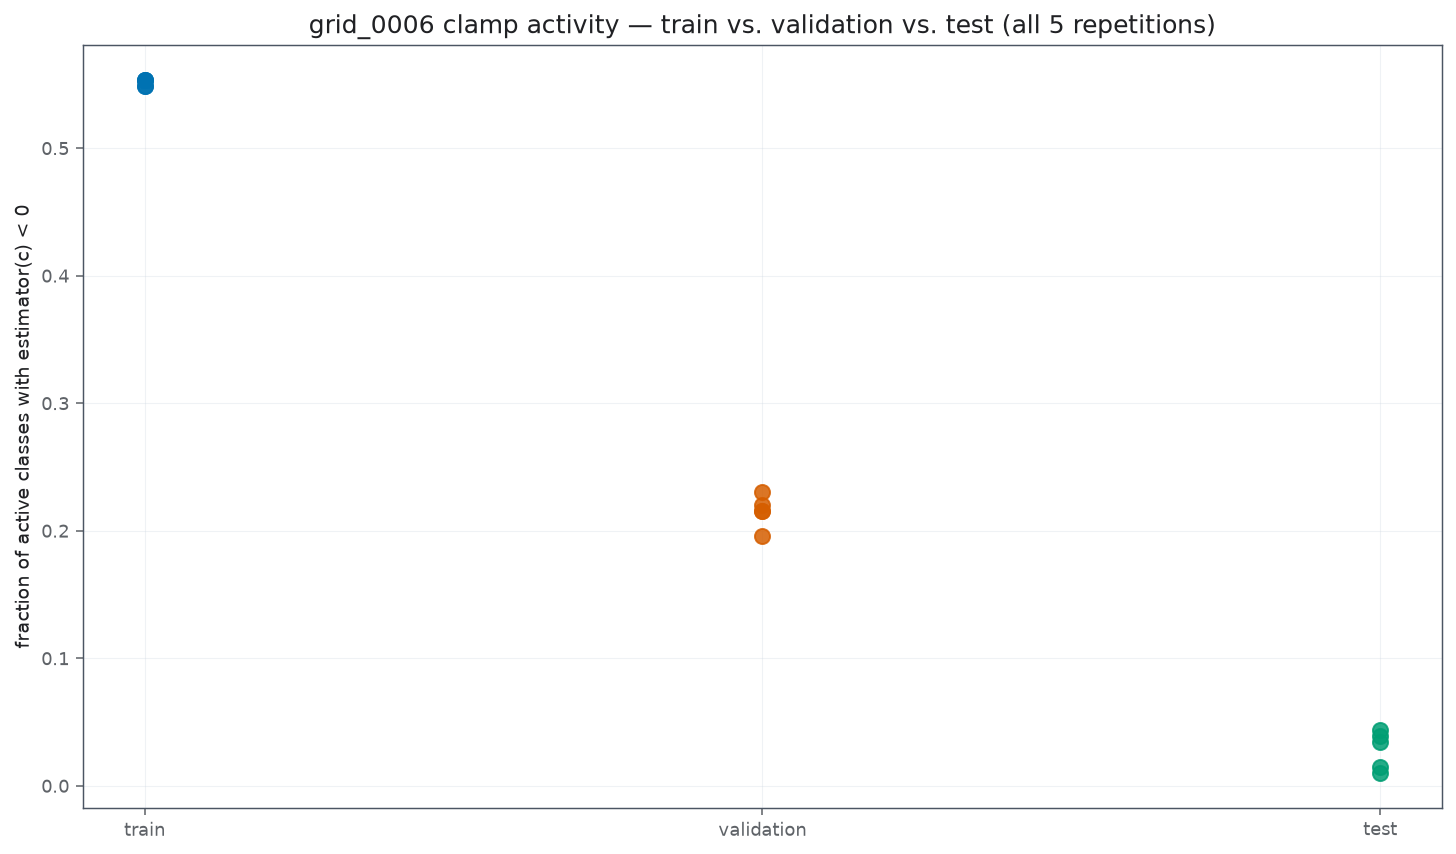

In [12]:
figure, ax = plt.subplots(figsize=theme.figure_size, dpi=theme.figure_dpi)
split_order = ["train", "validation", "test"]
for index, split_name in enumerate(split_order):
    values = cross_split_frame[(cross_split_frame["split"] == split_name) & (cross_split_frame["metryka"] == "fraction_negative_estimator")]["wartość"]
    x = np.full(len(values), index, dtype=float)
    ax.scatter(x, values, color=theme.color_for_model(split_name, index), label=split_name, alpha=theme.primary_alpha, s=60)
ax.set_xticks(range(len(split_order)))
ax.set_xticklabels(split_order)
ax.set(ylabel="fraction of active classes with estimator(c) < 0", title="grid_0006 clamp activity — train vs. validation vs. test (all 5 repetitions)")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

# Extends the required campaign/variant/repetition/metryka/wartość schema with a `split`
# column — the cross-split check was not part of the original spec, and cramming three
# splits into the `metryka` string would make this harder to query, not easier.
cross_split_frame.to_csv(RESULTS_DIRECTORY / "clamp_diagnostics_by_split.csv", index=False)
print(f"wrote {RESULTS_DIRECTORY / 'clamp_diagnostics_by_split.csv'} ({len(cross_split_frame)} rows)")


## Notes for the next pass

**Headline: the nnPU non-negative correction is real and active — not vacuous, and its
activity pattern across splits is exactly what Kiryo et al.'s (2017) motivation for the
correction predicts.**

### Result (`grid_0006`, all 5 repetitions, 204/508 active classes)

| split | fraction with `estimator(c) < 0` | mean `estimator(c)` | median `estimator(c)` |
|---|---|---|---|
| `train` | 0.549 – 0.554 | −0.38 to −0.44 | −0.016 to −0.028 |
| `validation` | 0.196 – 0.230 | +0.045 to +0.083 | ≈ +0.001 to +0.002 |
| `test` | 0.010 – 0.044 | +0.094 to +0.159 | +0.011 to +0.022 |

- **On `train`, the clamp fires for roughly half of all active classes**, very
  consistently across all 5 independently-initialized repetitions (54.9-55.4%) — this
  is unambiguous evidence the `max(0, .)` correction is doing real work, not sitting
  permanently inactive (which would indicate the model had degenerated to plain,
  biased uPU despite the `NNPUMultiLabelLoss` label). This directly answers this
  notebook's opening question: `grid_0006` trained genuine nnPU.
- **The mean/median divergence on `train` is itself informative**: mean −0.38 to −0.44
  vs. median only −0.016 to −0.028 means the distribution is heavily skewed — most
  active classes sit close to the clamp boundary, while a smaller number of classes
  have a strongly negative raw estimator pulling the mean down hard. Worth a follow-up
  look at which specific classes drive that tail (likely the highest-prevalence
  classes, where $\pi_c \cdot R_P^-(c)$ has the most room to exceed $R_U^-(c)$).
- **The clamp essentially never fires on `test`** (1.0-4.4% of active classes) and only
  occasionally on `validation` (19.6-23.0%) — a clean, monotonic train > validation >
  test ordering, mirroring exactly how much each split was "seen" by the optimization
  (`validation` informs checkpoint selection but not gradients; `test` informs
  nothing). **This is not a discrepancy to be worried about** — it is the expected
  signature of nnPU's correction doing its designed job: the raw (uncorrected) PU risk
  estimator tends toward negative specifically as the classifier overfits the
  training objective it was fit against, which is a `train`-specific phenomenon by
  construction. Finding the clamp *inactive* on held-out data is consistent with a
  well-behaved fit, not evidence the correction is unnecessary in general — without it,
  the *training* dynamics (not the held-out numbers) would have been free to chase an
  unboundedly negative empirical risk on `train`.

**Artifacts written**: `clamp_diagnostics.csv` (20 rows, `train` only, matching the
spec's required schema), `clamp_diagnostics_per_class.csv` (1020 rows, per-class raw
values for reproducing the histogram), `clamp_diagnostics_by_split.csv` (the
  train/validation/test extension above, schema extended with a `split` column).
